# PPO from scratch - Notebook 3

The goal is to write the learning code yourself. This notebook is only an
order of attack, a few interfaces, and checkpoints that tell you when to
move on. It intentionally does not contain implementations of the policy,
GAE, or PPO loss.

Start with the fixed-payload `sample_landing` task. Do not begin with the
full mission, curriculum scheduling, or payload randomization.

It is fine to keep the first working version here. Once an update step
works, move reusable pieces into ordinary `.py` files and give the math
functions small unit tests.

In [15]:
from pathlib import Path
import sys
sys.path.insert(0, "..")

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'rocketenv').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Launch Jupyter from the RocketRL repository or its learning folder')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn

from rocketenv.sample_return import (
    OBSERVATION_DIM,
    OBSERVATION_NAMES,
    TrainingTask,
    make_training_env,
)

torch.manual_seed(0)
np.random.seed(0)

env = make_training_env(
    task=TrainingTask.SAMPLE_LANDING,
    action_repeat=4,
)
observation, info = env.reset(seed=0)

print('observation:', observation.shape, observation.dtype)
print('action space:', env.action_space)
print('task:', info['task'])
assert observation.shape == (OBSERVATION_DIM,)


observation: (16,) float32
action space: Box([ 0. -1.], 1.0, (2,), float32)
task: sample_landing


---
## 1. Build the stochastic actor and critic

This is the first code to write.

- The actor takes one 16-value observation and defines a distribution over
  throttle and gimbal.
- The critic takes the same observation and produces one scalar value.
- Choose how the actor respects `[0, 1] x [-1, 1]`. Do not rely on the
  environment clipping an unbounded Gaussian, because then the stored log
  probability may describe a different action from the applied one.

Before continuing, check only this: a batch goes in, bounded actions come
out, each action has one finite log probability, and the critic returns one
value per observation.

In [16]:
# Define your actor and critic here.

class Actor(nn.Module):
    def __init__(self, OBSERVATION_DIM, HIDDEN_WIDTH, OUTPUTSIZE):
        super().__init__()
        self.layer1 = nn.Linear(OBSERVATION_DIM, HIDDEN_WIDTH)
        self.layer2 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH)
        self.mean_head = nn.Linear(HIDDEN_WIDTH, OUTPUTSIZE)
        self.std_head = nn.Linear(HIDDEN_WIDTH, OUTPUTSIZE)
        
    def forward(self, x):
        x = self.layer1(x)
        x = torch.tanh(x)
        x = self.layer2(x)
        x = torch.tanh(x)
        
        mean = self.mean_head(x)
        std = self.std_head(x)
        
        return mean, std

    def distribution_parameters(self, observations):
        mean, log_std = self(observations)

        og_std = torch.clamp(log_std, -5.0, 1.0)
        std = log_std.exp()
        
        return mean, std
        

class Critic(nn.Module):
    def __init__(self, OBSERVATION_DIM, HIDDEN_WIDTH, OUTPUTSIZE):
        super().__init__()
        self.layer1 = nn.Linear(OBSERVATION_DIM, HIDDEN_WIDTH)
        self.layer2 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH)
        self.layer3 = nn.Linear(HIDDEN_WIDTH, OUTPUTSIZE)
        
    def forward(self, x):
        x = self.layer1(x)
        x = torch.tanh(x)
        x = self.layer2(x)
        x = torch.tanh(x)
        x = self.layer3(x)
        return x


---
## 2. Generate one episode without learning

Run the actor on one `sample_landing` episode. For every decision, retain
the observation, sampled action, its log probability, critic value, reward,
and both boundary flags. Reset the policy state at the start, even though
the first policy is feedforward.

Do not optimize anything yet. Inspect the trajectory and make sure the
arrays describe what actually happened. Most random policies will crash;
that is expected.

In [17]:
# Collect and inspect one episode here.
import math 

env = make_training_env(
    task=TrainingTask.SAMPLE_LANDING,
    action_repeat=4,
)
observation, info = env.reset(seed=0)
device = torch.device("cpu")

actorNetwork = Actor(OBSERVATION_DIM, 128, 2)
criticNetwork = Critic(OBSERVATION_DIM, 128, 1)

max_decisions = env.unwrapped.cfg.max_steps

observations = np.empty(
    (max_decisions, OBSERVATION_DIM),
    dtype=np.float32,
)
next_observations = np.empty(
    (max_decisions, OBSERVATION_DIM),
    dtype=np.float32,
)
means = np.empty((max_decisions, 2), dtype=np.float32)
stds = np.empty((max_decisions, 2), dtype=np.float32)
unclipped_actions = np.empty((max_decisions, 2), dtype=np.float32)
sampled_actions = np.empty((max_decisions, 2), dtype=np.float32)

rewards = np.empty(max_decisions, dtype=np.float32)
critic_estimates = np.empty(max_decisions, dtype=np.float32)
terminateds = np.empty(max_decisions, dtype=np.bool_)
truncateds = np.empty(max_decisions, dtype=np.bool_)
unbounded_logs = np.empty(max_decisions, dtype=np.float32)
bounded_logs = np.empty(max_decisions, dtype=np.float32)


def choose_action(observation_tensor):
    mean, std = actorNetwork.distribution_parameters(observation_tensor)

    dist = torch.distributions.Normal(mean, std)
    sampled_unbounded = dist.rsample()
    squashed = torch.tanh(sampled_unbounded)

    throttle = (squashed[..., 0] + 1.0) / 2.0
    gimbal = squashed[..., 1]
    sampled_action = torch.stack((throttle, gimbal), dim=-1)
    
    log_unbounded = dist.log_prob(sampled_unbounded).sum(dim=-1)
    
    log_bounded = (dist.log_prob(sampled_unbounded) - torch.log(1.0 - squashed.pow(2) + 1e-6)).sum(dim=-1) + math.log(2.0)
    

    return mean, std, sampled_unbounded, sampled_action, log_unbounded, log_bounded


T = 0

with torch.no_grad():
    for t in range(max_decisions):
        # All values at index t correspond to this observation.
        observations[t] = observation

        observation_tensor = torch.as_tensor(
            observation,
            dtype=torch.float32,
            device=device,
        )

        mean, std, unclipped, action_tensor, log_unbounded, log_bounded = choose_action(
            observation_tensor
        )
        value = criticNetwork(observation_tensor).squeeze(-1)

        means[t] = mean.detach().cpu().numpy()
        stds[t] = std.detach().cpu().numpy()
        unclipped_actions[t] = unclipped.detach().cpu().numpy()
        unbounded_logs[t] = log_unbounded.detach().cpu().numpy()
        bounded_logs[t] = log_bounded.detach().cpu().numpy()

        action = (
            action_tensor
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32, copy=False)
        )
        sampled_actions[t] = action
        critic_estimates[t] = value.item()
        
        (
            next_observation,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(action)

        next_observations[t] = next_observation
        rewards[t] = reward
        terminateds[t] = terminated
        truncateds[t] = truncated

        T = t + 1
        observation = next_observation

        if terminated or truncated:
            break


# Remove unused preallocated rows.
observations = observations[:T]
next_observations = next_observations[:T]
means = means[:T]
stds = stds[:T]
unclipped_actions = unclipped_actions[:T]
sampled_actions = sampled_actions[:T]
rewards = rewards[:T]
critic_estimates = critic_estimates[:T]
terminateds = terminateds[:T]
truncateds = truncateds[:T]
unbounded_logs = unbounded_logs[:T]
bounded_logs = bounded_logs[:T]



assert observations.shape == (T, OBSERVATION_DIM)
assert next_observations.shape == (T, OBSERVATION_DIM)
assert means.shape == stds.shape == (T, 2)
assert unclipped_actions.shape == sampled_actions.shape == (T, 2)
assert rewards.shape == critic_estimates.shape == (T,)
assert terminateds.shape == truncateds.shape == (T,)
assert terminateds[-1] or truncateds[-1]

for array in (
    observations,
    next_observations,
    means,
    stds,
    unclipped_actions,
    sampled_actions,
    rewards,
    critic_estimates,
):
    assert array.dtype == np.float32
    assert np.isfinite(array).all()

assert terminateds.dtype == np.bool_
assert truncateds.dtype == np.bool_

print("policy decisions:", T)
print("outcome:", info.get("outcome"))
print("observations:", observations.shape, observations.dtype)
print("sampled actions:", sampled_actions.shape, sampled_actions.dtype)
print("rewards:", rewards.shape, rewards.dtype)
print("critic estimates:", critic_estimates.shape, critic_estimates.dtype)
print("terminateds:", terminateds.shape, terminateds.dtype)
print("truncateds:", truncateds.shape, truncateds.dtype)
print("unbounded logs:", unbounded_logs.shape, truncateds.dtype)
print("bounded logs:", bounded_logs.shape, truncateds.dtype)

policy decisions: 78
outcome: CRASHED_OUTBOUND
observations: (78, 16) float32
sampled actions: (78, 2) float32
rewards: (78,) float32
critic estimates: (78,) float32
terminateds: (78,) bool
truncateds: (78,) bool
unbounded logs: (78,) bool
bounded logs: (78,) bool


sample count: 78
throttle range: 0.04758385 0.93902546
gimbal range: -0.9325824 0.90897006
fraction within action space: 1.0
episode return: -107.490425
terminated/truncated: True False


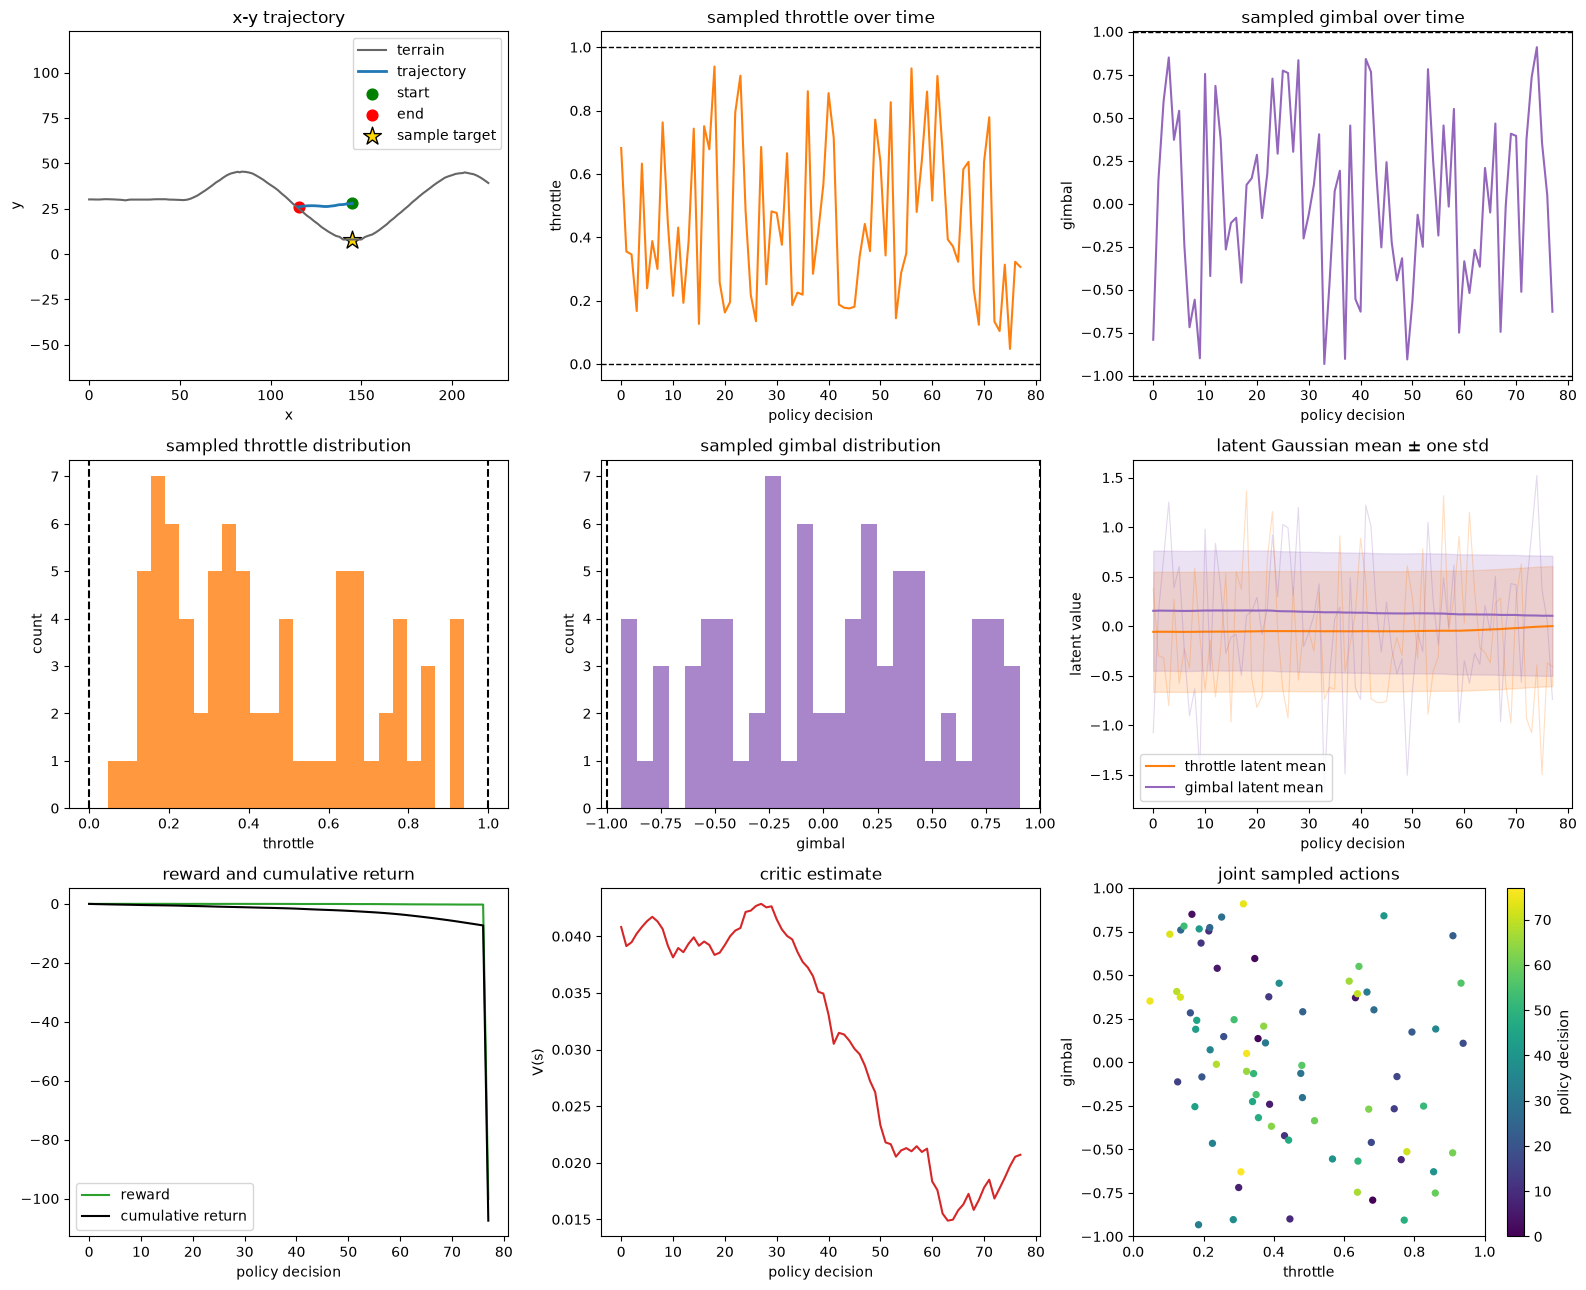

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from rocketenv.sample_return import OBSERVATION_INDEX


mission_env = env.mission_env

# SAMPLE_LANDING always targets the sample pad, so absolute position can be
# reconstructed from the normalized target-relative observation.
target_x = mission_env.sample_x
target_y = mission_env.terrain.height_at(target_x)

# observations contains s_t and the final row below adds s_(T).
trajectory_observations = np.concatenate(
    (observations, next_observations[-1:]),
    axis=0,
)

target_dx = trajectory_observations[
    :, OBSERVATION_INDEX["target_dx"]
]
target_dy = trajectory_observations[
    :, OBSERVATION_INDEX["target_dy"]
]

x = target_x - target_dx * mission_env.cfg.world_w
y = target_y - target_dy * mission_env.cfg.world_h

steps = np.arange(T)

print("sample count:", T)
print(
    "throttle range:",
    sampled_actions[:, 0].min(),
    sampled_actions[:, 0].max(),
)
print(
    "gimbal range:",
    sampled_actions[:, 1].min(),
    sampled_actions[:, 1].max(),
)

within_action_space = (
    (sampled_actions[:, 0] >= 0.0)
    & (sampled_actions[:, 0] <= 1.0)
    & (sampled_actions[:, 1] >= -1.0)
    & (sampled_actions[:, 1] <= 1.0)
)

print("fraction within action space:", within_action_space.mean())
print("episode return:", rewards.sum())
print(
    "terminated/truncated:",
    terminateds[-1],
    truncateds[-1],
)


fig, axes = plt.subplots(3, 3, figsize=(16, 13))


# Trajectory over terrain
axes[0, 0].plot(
    mission_env.terrain.xs,
    mission_env.terrain.ys,
    color="0.4",
    label="terrain",
)
axes[0, 0].plot(
    x,
    y,
    color="tab:blue",
    linewidth=2,
    label="trajectory",
)
axes[0, 0].scatter(
    x[0],
    y[0],
    color="green",
    s=60,
    label="start",
)
axes[0, 0].scatter(
    x[-1],
    y[-1],
    color="red",
    s=60,
    label="end",
)
axes[0, 0].scatter(
    target_x,
    target_y,
    marker="*",
    color="gold",
    edgecolor="black",
    s=180,
    label="sample target",
)
axes[0, 0].set_title("x-y trajectory")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].axis("equal")
axes[0, 0].legend()


# Sampled throttle over time
axes[0, 1].plot(
    steps,
    sampled_actions[:, 0],
    color="tab:orange",
)
axes[0, 1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0, 1].axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0, 1].set_title("sampled throttle over time")
axes[0, 1].set_xlabel("policy decision")
axes[0, 1].set_ylabel("throttle")


# Sampled gimbal over time
axes[0, 2].plot(
    steps,
    sampled_actions[:, 1],
    color="tab:purple",
)
axes[0, 2].axhline(
    -1.0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0, 2].axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0, 2].set_title("sampled gimbal over time")
axes[0, 2].set_xlabel("policy decision")
axes[0, 2].set_ylabel("gimbal")


# Histograms
axes[1, 0].hist(
    sampled_actions[:, 0],
    bins=25,
    color="tab:orange",
    alpha=0.8,
)
axes[1, 0].axvline(0.0, color="black", linestyle="--")
axes[1, 0].axvline(1.0, color="black", linestyle="--")
axes[1, 0].set_title("sampled throttle distribution")
axes[1, 0].set_xlabel("throttle")
axes[1, 0].set_ylabel("count")

axes[1, 1].hist(
    sampled_actions[:, 1],
    bins=25,
    color="tab:purple",
    alpha=0.8,
)
axes[1, 1].axvline(-1.0, color="black", linestyle="--")
axes[1, 1].axvline(1.0, color="black", linestyle="--")
axes[1, 1].set_title("sampled gimbal distribution")
axes[1, 1].set_xlabel("gimbal")
axes[1, 1].set_ylabel("count")


# Latent Gaussian means, samples, and one-standard-deviation bands.
for dimension, label, color in (
    (0, "throttle latent", "tab:orange"),
    (1, "gimbal latent", "tab:purple"),
):
    mean = means[:, dimension]
    std = stds[:, dimension]

    axes[1, 2].plot(
        steps,
        mean,
        label=f"{label} mean",
        color=color,
    )
    axes[1, 2].plot(
        steps,
        unclipped_actions[:, dimension],
        color=color,
        alpha=0.25,
        linewidth=0.8,
    )
    axes[1, 2].fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.18,
    )

axes[1, 2].set_title("latent Gaussian mean ± one std")
axes[1, 2].set_xlabel("policy decision")
axes[1, 2].set_ylabel("latent value")
axes[1, 2].legend()


# Immediate reward and cumulative episode return
axes[2, 0].plot(
    steps,
    rewards,
    color="tab:green",
    label="reward",
)
axes[2, 0].plot(
    steps,
    np.cumsum(rewards),
    color="black",
    label="cumulative return",
)
axes[2, 0].set_title("reward and cumulative return")
axes[2, 0].set_xlabel("policy decision")
axes[2, 0].legend()


# This critic is still randomly initialized.
axes[2, 1].plot(
    steps,
    critic_estimates,
    color="tab:red",
)
axes[2, 1].set_title("critic estimate")
axes[2, 1].set_xlabel("policy decision")
axes[2, 1].set_ylabel("V(s)")


# Joint action samples, colored by time
scatter = axes[2, 2].scatter(
    sampled_actions[:, 0],
    sampled_actions[:, 1],
    c=steps,
    cmap="viridis",
    s=18,
)
axes[2, 2].set_xlim(0.0, 1.0)
axes[2, 2].set_ylim(-1.0, 1.0)
axes[2, 2].set_title("joint sampled actions")
axes[2, 2].set_xlabel("throttle")
axes[2, 2].set_ylabel("gimbal")
fig.colorbar(
    scatter,
    ax=axes[2, 2],
    label="policy decision",
)

fig.tight_layout()
plt.show()

---
## 3. Turn that into a fixed-horizon rollout batch

Once one episode is understandable, switch to `make_vector_env`. Store a
fixed number of policy decisions with leading dimensions `(time, env)`.
Preserve terminal observations before explicitly resetting completed slots.
The vector environments deliberately do not autoreset.

At this checkpoint, verify shapes, action bounds, finite rewards, and that
decision steps are distinct from the underlying 60 Hz physics steps.

In [19]:
from rocketenv.sample_return import (
    TrainingTask,
    make_vector_env,
)

N = 8
ROLLOUT_STEPS = 512

environments = make_vector_env(
    N,
    task=TrainingTask.SAMPLE_LANDING,
    action_repeat=4,
)

observations, reset_info = environments.reset(
    seed=[100 + i for i in range(N)]
)

device = torch.device("cpu")

actorNetwork = Actor(OBSERVATION_DIM, 128, 2).to(device)
criticNetwork = Critic(OBSERVATION_DIM, 128, 1).to(device)

observations_matrix = np.empty(
    (ROLLOUT_STEPS, N, OBSERVATION_DIM),
    dtype=np.float32,
)
next_observations_matrix = np.empty(
    (ROLLOUT_STEPS, N, OBSERVATION_DIM),
    dtype=np.float32,
)

means_matrix = np.empty(
    (ROLLOUT_STEPS, N, 2),
    dtype=np.float32,
)
stds_matrix = np.empty(
    (ROLLOUT_STEPS, N, 2),
    dtype=np.float32,
)
unclipped_actions_matrix = np.empty(
    (ROLLOUT_STEPS, N, 2),
    dtype=np.float32,
)
sampled_actions_matrix = np.empty(
    (ROLLOUT_STEPS, N, 2),
    dtype=np.float32,
)

rewards_matrix = np.empty(
    (ROLLOUT_STEPS, N),
    dtype=np.float32,
)
critic_estimates_matrix = np.empty(
    (ROLLOUT_STEPS, N),
    dtype=np.float32,
)
bootstrap_values_matrix = np.empty(
    (ROLLOUT_STEPS, N),
    dtype=np.float32,
)

terminated_matrix = np.empty(
    (ROLLOUT_STEPS, N),
    dtype=np.bool_,
)
truncated_matrix = np.empty(
    (ROLLOUT_STEPS, N),
    dtype=np.bool_,
)

unbounded_logs_matrix = np.empty(
    (ROLLOUT_STEPS, N),
    dtype=np.float32,
)
bounded_logs_matrix = np.empty(
    (ROLLOUT_STEPS, N),
    dtype=np.float32,
)


def choose_action(actorNetwork, observation_tensor):
    mean, std = actorNetwork.distribution_parameters(observation_tensor)

    dist = torch.distributions.Normal(mean, std)
    sampled_unbounded = dist.rsample()
    squashed = torch.tanh(sampled_unbounded)

    throttle = (squashed[..., 0] + 1.0) / 2.0
    gimbal = squashed[..., 1]
    sampled_action = torch.stack(
        (throttle, gimbal),
        dim=-1,
    )

    component_log_prob = dist.log_prob(sampled_unbounded)

    log_unbounded = component_log_prob.sum(dim=-1)

    log_bounded = (
        component_log_prob
        - torch.log(1.0 - squashed.pow(2) + 1e-6)
    ).sum(dim=-1) + math.log(2.0)

    return (
        mean,
        std,
        sampled_unbounded,
        sampled_action,
        log_unbounded,
        log_bounded,
    )


actorNetwork.eval()
criticNetwork.eval()

with torch.no_grad():
    for t in range(ROLLOUT_STEPS):
        # Shape: (N, OBSERVATION_DIM)
        observations_matrix[t] = observations

        observation_tensor = torch.as_tensor(
            observations,
            dtype=torch.float32,
            device=device,
        )

        (
            mean,
            std,
            sampled_unbounded,
            action_tensor,
            log_unbounded,
            log_bounded,
        ) = choose_action(observation_tensor)

        value_tensor = criticNetwork(
            observation_tensor
        ).squeeze(-1)

        means_matrix[t] = mean.cpu().numpy()
        stds_matrix[t] = std.cpu().numpy()
        unclipped_actions_matrix[t] = sampled_unbounded.cpu().numpy()
        unbounded_logs_matrix[t] = log_unbounded.cpu().numpy()
        bounded_logs_matrix[t] = log_bounded.cpu().numpy()
        critic_estimates_matrix[t] = value_tensor.cpu().numpy()

        actions = (
            action_tensor
            .cpu()
            .numpy()
            .astype(np.float32, copy=False)
        )
        sampled_actions_matrix[t] = actions

        (
            next_observations,
            rewards,
            terminated,
            truncated,
            step_info,
        ) = environments.step(actions)

        # Save these before resetting. Done rows contain their true terminal
        # observations here, which truncations need for bootstrapping.
        next_observations_matrix[t] = next_observations
        rewards_matrix[t] = rewards
        terminated_matrix[t] = terminated
        truncated_matrix[t] = truncated

        next_observation_tensor = torch.as_tensor(
            next_observations,
            dtype=torch.float32,
            device=device,
        )

        next_values = (
            criticNetwork(next_observation_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

        # A true terminal state has no future value.
        # A truncated state still bootstraps from V(terminal_observation).
        bootstrap_values = next_values.copy()
        bootstrap_values[terminated] = 0.0
        bootstrap_values_matrix[t] = bootstrap_values

        done = np.logical_or(terminated, truncated)

        if done.any():
            # True rows receive fresh episode observations.
            # False rows keep their current next observations.
            observations, reset_info = environments.reset(
                options={"reset_mask": done}
            )
        else:
            observations = next_observations

In [26]:
@torch.no_grad()
def collect_rollout(
    environments,
    observations,
    actorNetwork,
    criticNetwork,
    rollout_steps,
):
    observations_matrix = np.empty(
        (ROLLOUT_STEPS, N, OBSERVATION_DIM),
        dtype=np.float32,
    )
    next_observations_matrix = np.empty(
        (ROLLOUT_STEPS, N, OBSERVATION_DIM),
        dtype=np.float32,
    )

    means_matrix = np.empty(
        (ROLLOUT_STEPS, N, 2),
        dtype=np.float32,
    )
    stds_matrix = np.empty(
        (ROLLOUT_STEPS, N, 2),
        dtype=np.float32,
    )
    unclipped_actions_matrix = np.empty(
        (ROLLOUT_STEPS, N, 2),
        dtype=np.float32,
    )
    sampled_actions_matrix = np.empty(
        (ROLLOUT_STEPS, N, 2),
        dtype=np.float32,
    )

    rewards_matrix = np.empty(
        (ROLLOUT_STEPS, N),
        dtype=np.float32,
    )
    critic_estimates_matrix = np.empty(
        (ROLLOUT_STEPS, N),
        dtype=np.float32,
    )
    bootstrap_values_matrix = np.empty(
        (ROLLOUT_STEPS, N),
        dtype=np.float32,
    )

    terminated_matrix = np.empty(
        (ROLLOUT_STEPS, N),
        dtype=np.bool_,
    )
    truncated_matrix = np.empty(
        (ROLLOUT_STEPS, N),
        dtype=np.bool_,
    )

    unbounded_logs_matrix = np.empty(
        (ROLLOUT_STEPS, N),
        dtype=np.float32,
    )
    bounded_logs_matrix = np.empty(
        (ROLLOUT_STEPS, N),
        dtype=np.float32,
    )

    for t in range(rollout_steps):
        # Shape: (N, OBSERVATION_DIM)
        observations_matrix[t] = observations

        observation_tensor = torch.as_tensor(
            observations,
            dtype=torch.float32,
            device=device,
        )

        (
            mean,
            std,
            sampled_unbounded,
            action_tensor,
            log_unbounded,
            log_bounded,
        ) = choose_action(observation_tensor)

        value_tensor = criticNetwork(
            observation_tensor
        ).squeeze(-1)

        means_matrix[t] = mean.cpu().numpy()
        stds_matrix[t] = std.cpu().numpy()
        unclipped_actions_matrix[t] = sampled_unbounded.cpu().numpy()
        unbounded_logs_matrix[t] = log_unbounded.cpu().numpy()
        bounded_logs_matrix[t] = log_bounded.cpu().numpy()
        critic_estimates_matrix[t] = value_tensor.cpu().numpy()

        actions = (
            action_tensor
            .cpu()
            .numpy()
            .astype(np.float32, copy=False)
        )
        sampled_actions_matrix[t] = actions

        (
            next_observations,
            rewards,
            terminated,
            truncated,
            step_info,
        ) = environments.step(actions)

        # Save these before resetting. Done rows contain their true terminal
        # observations here, which truncations need for bootstrapping.
        next_observations_matrix[t] = next_observations
        rewards_matrix[t] = rewards
        terminated_matrix[t] = terminated
        truncated_matrix[t] = truncated

        next_observation_tensor = torch.as_tensor(
            next_observations,
            dtype=torch.float32,
            device=device,
        )

        next_values = (
            criticNetwork(next_observation_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

        # A true terminal state has no future value.
        # A truncated state still bootstraps from V(terminal_observation).
        bootstrap_values = next_values.copy()
        bootstrap_values[terminated] = 0.0
        bootstrap_values_matrix[t] = bootstrap_values

        done = np.logical_or(terminated, truncated)

        if done.any():
            # True rows receive fresh episode observations.
            # False rows keep their current next observations.
            observations, reset_info = environments.reset(
                options={"reset_mask": done}
            )
        else:
            observations = next_observations

    rollout_data = {
        "observations": observations_matrix,
        "next_observations": next_observations_matrix,
        "means": means_matrix,
        "stds": stds_matrix,
        "unclipped_actions": unclipped_actions_matrix,
        "actions": sampled_actions_matrix,
        "rewards": rewards_matrix,
        "values": critic_estimates_matrix,
        "bootstrap_values": bootstrap_values_matrix,
        "terminated": terminated_matrix,
        "truncated": truncated_matrix,
        "unbounded_log_probs": unbounded_logs_matrix,
        "log_probs": bounded_logs_matrix,
    }

    return rollout_data, observations

---
## 4. Compute advantages

Implement ordinary discounted returns first, then GAE. Test both on a tiny
trajectory whose answer you calculate by hand before using rollout data.

Remember the only boundary distinction needed here:

- a true termination has bootstrap value zero;
- a timeout truncation bootstraps from the terminal observation's value;
- the backwards recurrence stops at either boundary.

In [20]:
# Implement and test returns / GAE here.
@torch.no_grad()
def compute_gae(data, gamma=0.99, lam=0.95):
    rewards = data["rewards"]
    values = data["values"]
    bootstrap_values = data["bootstrap_values"]
    terminated = data["terminated"]
    truncated = data["truncated"]

    deltas = (rewards - values) + (gamma * bootstrap_values * (1 - terminated))
    done = 1.0 - np.maximum(terminated, truncated)

    advantages = np.zeros_like(rewards)
    gae = np.zeros_like(rewards[0])
    for t in reversed(range(rewards.shape[0])):
        gae = deltas[t] + (gamma * lam * done[t] * gae)
        advantages[t] = gae

    return advantages, advantages + values

# ok so now we use this ne

---
## 5. Make one PPO update

Only after the rollout and advantages are trustworthy, add the clipped
policy objective, critic loss, and entropy term. Keep the old log
probabilities fixed. Shuffle the rollout into minibatches and update for a
small number of epochs.

Useful checks before attempting a long run:

- the probability ratio is approximately one before the first update;
- actor and critic parameters change after an update;
- old log probabilities do not acquire gradients;
- loss, entropy, approximate KL, and clip fraction remain finite.

In [21]:
# Implement one PPO update here.
'''
1. Collect rollout with policy θ_old  (no_grad)
     store: obs, actions, old_logprobs, rewards, dones, values
2. Compute advantages + returns ONCE      ← frozen from here on

3. For K epochs (typically 4–10):
     shuffle, split into minibatches, and for each:
       forward actor+critic on the STORED obs
       ratio = exp(new_logprob - old_logprob)
       clipped surrogate loss + value loss + entropy bonus
       backward, clip grad norm, step
4. Throw the buffer away, go to 1

'''
def squashed_log_prob(normal, raw_action, action):
    base_log_prob = normal.log_prob(raw_action)

    base_log_prob = base_log_prob.sum(dim=-1)

    correction = torch.log(
        1.0 - action.pow(2) + 1e-6
    ).sum(dim=-1)

    return base_log_prob - correction


# we'll have the rollout already so env is not relevant here
def ppo_update(actor,
    critic,
    actor_optimizer,
    critic_optimizer,
    data,
    gae_advantages,
    returns,
    epochs=4,
    batch_size=256,
    clip_epsilon=0.2):
        observations = data["observations"]

        n = len(observations)
    
        
    
        for k in range(epochs):
            perm = torch.randperm(n)
            for i in range(0, n, batch_size):
                idx = perm[i : i + batch_size]

                observations = data["observations"][idx]

                actions = data["actions"][idx]
    
                unclipped_actions = data["unclipped_actions"][batch_indices]
    
                old_log_probs = data["log_probs"][batch_indices]

    
                batch_advantages = advantages[batch_indices]
    
                batch_returns = returns[batch_indices]
                
                mu, std = actor(observations)
                
                newfunc = torch.Normal(mu, std)

                new_log_probs = squashed_log_prob(newfunc, actions, unclipped_actions)

                ratio = torch.exp(
                    new_log_probs - old_log_probs
                )
    
                objective_unclipped = (
                    ratio * batch_advantages
                )
    
                clipped_ratio = torch.clamp(
                    ratio,
                    1.0 - clip_epsilon,
                    1.0 + clip_epsilon
                )
    
                objective_clipped = (
                    clipped_ratio
                    * batch_advantages
                )
    
                actor_objective = torch.min(
                    objective_unclipped,
                    objective_clipped
                )

                actor_loss = -actor_objective.mean()

                actor_optimizer.zero_grad()
    
                actor_loss.backward()
    
                actor_optimizer.step()

                # Critic

                values = critic(values)

                critic_loss = (0.5 * (values - gae) ** 2).mean()

                 critic_optimizer.zero_grad()
    
                critic_loss.backward()
    
                critic_optimizer.step()
            
        


---
## 6. First training experiment

Train only `sample_landing`. First prove the code can improve on a very
small, fixed start distribution. Then widen the spawn perturbations and use
several training seeds. Plot physical success rate alongside return; reward
going up is not enough by itself.

When that works, move in order to `return_landing`, the two full legs, and
finally `full_mission`. Continue using the same policy. Keep the payload
fixed until the complete-mission baseline is working.

In [22]:
# Put the first training loop and plots here.
